# Developer Code Defect Prediction

## Exploratory Data Analysis

This project uses Machine Learning to predict whether a software module is likely to contain defects based on software engineering metrics.

The JM1 software defect dataset is used for analysis.

### Objectives

- Understand the software defect dataset
- Analyze software engineering metrics
- Examine defective and non-defective modules
- Identify missing and duplicate records
- Analyze feature distributions
- Study relationships between software metrics and defects
- Prepare the dataset for Machine Learning

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Dataset Loading

The JM1 dataset contains software engineering metrics collected from software modules.

The target variable `defects` indicates whether a software module contains a defect.

In [3]:
df = pd.read_csv("../data/jm1.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (10885, 22)


,loc,v(g),ev(g),iv(g),n,v,l,d,i,e,...,lOCode,lOComment,lOBlank,locCodeAndComment,uniq_Op,uniq_Opnd,total_Op,total_Opnd,branchCount,defects
0,1.1,1.4,1.4,1.4,1.3,1.30,1.30,1.30,1.30,1.30,...,2,2,2,2,1.2,1.2,1.2,1.2,1.4,False
1,1.0,1.0,1.0,1.0,1.0,1.00,1.00,1.00,1.00,1.00,...,1,1,1,1,1,1,1,1,1,True
2,72.0,7.0,1.0,6.0,198.0,1134.13,0.05,20.31,55.85,23029.10,...,51,10,8,1,17,36,112,86,13,True
3,190.0,3.0,1.0,3.0,600.0,4348.76,0.06,17.06,254.87,74202.67,...,129,29,28,2,17,135,329,271,5,True
4,37.0,4.0,1.0,4.0,126.0,599.12,0.06,17.19,34.86,10297.30,...,28,1,6,0,11,16,76,50,7,True


## 2. Dataset Dimensions

The dataset contains software metrics for multiple software modules.

The number of rows represents software modules, while the columns represent software engineering metrics and the target variable.

In [4]:
rows, columns = df.shape

print("Number of rows:", rows)
print("Number of columns:", columns)

Number of rows: 10885
Number of columns: 22


## 3. Dataset Features

The dataset contains software engineering metrics related to code size, complexity, operators, operands, and control flow.

In [5]:
print("Column names:")

for column in df.columns:
    print(column)

Column names:
loc
v(g)
ev(g)
iv(g)
n
v
l
d
i
e
b
t
lOCode
lOComment
lOBlank
locCodeAndComment
uniq_Op
uniq_Opnd
total_Op
total_Opnd
branchCount
defects


## 4. Dataset Structure

The data types of each column are examined to identify numerical, categorical, and target variables.

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10885 entries, 0 to 10884
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   loc                10885 non-null  float64
 1   v(g)               10885 non-null  float64
 2   ev(g)              10885 non-null  float64
 3   iv(g)              10885 non-null  float64
 4   n                  10885 non-null  float64
 5   v                  10885 non-null  float64
 6   l                  10885 non-null  float64
 7   d                  10885 non-null  float64
 8   i                  10885 non-null  float64
 9   e                  10885 non-null  float64
 10  b                  10885 non-null  float64
 11  t                  10885 non-null  float64
 12  lOCode             10885 non-null  int64  
 13  lOComment          10885 non-null  int64  
 14  lOBlank            10885 non-null  int64  
 15  locCodeAndComment  10885 non-null  int64  
 16  uniq_Op            10885 non-null

## 5. Statistical Summary

Descriptive statistics are calculated to understand the distribution and range of the numerical software metrics.

In [7]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
loc,10885.0,NaN,NaN,NaN,42.016178,76.593332,1.0,11.0,23.0,46.0,3442.0
v(g),10885.0,NaN,NaN,NaN,6.34859,13.019695,1.0,2.0,3.0,7.0,470.0
ev(g),10885.0,NaN,NaN,NaN,3.401047,6.771869,1.0,1.0,1.0,3.0,165.0
iv(g),10885.0,NaN,NaN,NaN,4.001599,9.116889,1.0,1.0,2.0,4.0,402.0
n,10885.0,NaN,NaN,NaN,114.389738,249.502091,0.0,14.0,49.0,119.0,8441.0
v,10885.0,NaN,NaN,NaN,673.758017,1938.856196,0.0,48.43,217.13,621.48,80843.08
l,10885.0,NaN,NaN,NaN,0.135335,0.160538,0.0,0.03,0.08,0.16,1.3
d,10885.0,NaN,NaN,NaN,14.177237,18.7099,0.0,3.0,9.09,18.9,418.2
i,10885.0,NaN,NaN,NaN,29.439544,34.418313,0.0,11.86,21.93,36.78,569.78
e,10885.0,NaN,NaN,NaN,36836.365343,434367.801255,0.0,161.94,2031.02,11416.43,31079782.27


## 6. Missing Value Analysis

Missing values are checked across all features and the target variable.

Identifying missing values is important before applying Machine Learning algorithms.

In [8]:
missing_values = df.isnull().sum()

missing_values

loc                  0
v(g)                 0
ev(g)                0
iv(g)                0
n                    0
v                    0
l                    0
d                    0
i                    0
e                    0
b                    0
t                    0
lOCode               0
lOComment            0
lOBlank              0
locCodeAndComment    0
uniq_Op              0
uniq_Opnd            0
total_Op             0
total_Opnd           0
branchCount          0
defects              0
dtype: int64

In [9]:
print("Total missing values:", missing_values.sum())

Total missing values: 0


## 7. Duplicate Record Analysis

Duplicate records are checked to determine whether identical software-module observations are present in the dataset.

Removing unintended duplicates helps prevent repeated observations from affecting Machine Learning evaluation.

In [10]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 1973


In [11]:
print("Percentage of duplicate records:",
      round((duplicate_count / len(df)) * 100, 2), "%")

Percentage of duplicate records: 18.13 %


## 8. Duplicate Record Investigation

A relatively high number of duplicate metric records was identified.

Before removing duplicates, the relationship between duplicate metric observations and their defect labels is examined. This determines whether identical software-metric profiles can have different defect outcomes.

In [14]:
# Identify feature columns
duplicate_feature_columns = [
    col for col in df.columns
    if col != "defects"
]

# Find rows that have duplicate metric values
duplicate_rows = df[
    df.duplicated(
        subset=duplicate_feature_columns,
        keep=False
    )
].copy()

# Check whether duplicate metric groups have different labels
duplicate_label_check = (
    duplicate_rows
    .groupby(duplicate_feature_columns)["defects"]
    .nunique()
)

print(
    "Duplicate metric groups with different defect labels:",
    (duplicate_label_check > 1).sum()
)

print(
    "Total duplicate metric groups:",
    len(duplicate_label_check)
)

Duplicate metric groups with different defect labels: 88
Total duplicate metric groups: 669


## 9. Duplicate Record Handling

The dataset contains duplicate software-metric records.

Most duplicate metric groups have the same defect label, while a small number have different labels. To reduce the risk of data leakage during Machine Learning evaluation, exact duplicate rows are removed.

The original dataset is kept unchanged, and duplicate removal is performed on the working DataFrame.

In [ ]:
original_rows = len(df)

df = df.drop_duplicates().reset_index(drop=True)

removed_rows = original_rows - len(df)

print("Original number of rows:", original_rows)
print("Duplicate rows removed:", removed_rows)
print("Rows after duplicate removal:", len(df))
print("Remaining duplicate rows:", df.duplicated().sum())

Original number of rows: 8912
Duplicate rows removed: 0
Rows after duplicate removal: 8912
Remaining duplicate rows: 0


## 10. Numeric Feature Type Conversion

Some software metrics are stored as strings even though they represent numerical values.

These columns are inspected and converted to numeric format before Machine Learning.

In [ ]:
string_columns = [
    "uniq_Op",
    "uniq_Opnd",
    "total_Op",
    "total_Opnd",
    "branchCount"
]

for column in string_columns:
    print(f"\n{column}:")
    print(df[column].head(10).tolist())


uniq_Op:
['1.2', '1', '17', '17', '11', '14', '0', '4', '0', '0']

uniq_Opnd:
['1.2', '1', '36', '135', '16', '24', '0', '5', '0', '0']

total_Op:
['1.2', '1', '112', '329', '76', '69', '0', '9', '0', '0']

total_Opnd:
['1.2', '1', '86', '271', '50', '42', '0', '7', '0', '0']

branchCount:
['1.4', '1', '13', '5', '7', '3', '17', '1', '3', '43']


for column in string_columns:
    df[column] = pd.to_numeric(df[column])

print("Conversion completed successfully!")

print("\nUpdated data types:")
print(df[string_columns].dtypes)

In [ ]:
for column in string_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

print("Conversion completed successfully!")

print("\nUpdated data types:")
print(df[string_columns].dtypes)

Conversion completed successfully!

Updated data types:
uniq_Op        float64
uniq_Opnd      float64
total_Op       float64
total_Opnd     float64
branchCount    float64
dtype: object


In [ ]:
print("Missing values after numeric conversion:")

print(df[string_columns].isnull().sum())

print("\nTotal new missing values:",
      df[string_columns].isnull().sum().sum())

Missing values after numeric conversion:
uniq_Op        5
uniq_Opnd      5
total_Op       5
total_Opnd     5
branchCount    5
dtype: int64

Total new missing values: 25


## 11. Missing Value Handling

After converting the numeric-looking columns, 25 invalid values were identified and converted to missing values.

The missing values are handled using median imputation. Median imputation is suitable for software metrics because several features have skewed distributions and extreme values.

In [ ]:
for column in string_columns:
    df[column] = df[column].fillna(df[column].median())

print("Missing values after median imputation:")
print(df[string_columns].isnull().sum())

print("\nTotal missing values:",
      df.isnull().sum().sum())

Missing values after median imputation:
uniq_Op        0
uniq_Opnd      0
total_Op       0
total_Opnd     0
branchCount    0
dtype: int64

Total missing values: 0


## 12. Target Variable Preparation

The `defects` column indicates whether a software module contains a defect.

- `True` represents a defective module
- `False` represents a non-defective module

The target is converted to binary values for Machine Learning.

In [ ]:
df["defects"] = df["defects"].astype(int)

print("Target data type:", df["defects"].dtype)

print("\nTarget values:")
print(df["defects"].value_counts())

Target data type: int64

Target values:
defects
0    6905
1    2007
Name: count, dtype: int64


In [ ]:
class_counts = df["defects"].value_counts()

print("Non-defective modules (0):", class_counts.get(0, 0))
print("Defective modules (1):", class_counts.get(1, 0))

print("\nDefective percentage:",
      round((class_counts.get(1, 0) / len(df)) * 100, 2), "%")

Non-defective modules (0): 6905
Defective modules (1): 2007

Defective percentage: 22.52 %


## 13. Defect Class Distribution

The distribution of defective and non-defective software modules is visualized to understand the class balance in the dataset.

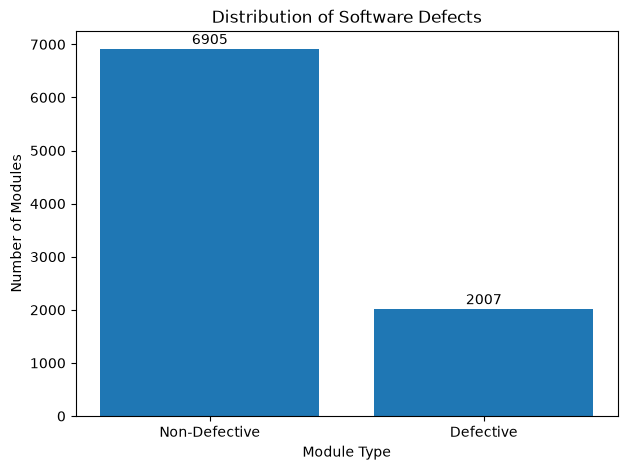

In [ ]:
class_counts = df["defects"].value_counts().sort_index()

plt.figure(figsize=(7, 5))

plt.bar(
    ["Non-Defective", "Defective"],
    class_counts.values
)

plt.title("Distribution of Software Defects")
plt.xlabel("Module Type")
plt.ylabel("Number of Modules")

for i, value in enumerate(class_counts.values):
    plt.text(i, value + 100, str(value), ha="center")

plt.show()

### Observation

The dataset contains more non-defective modules than defective modules.

Approximately 22.52% of the modules are defective, indicating moderate class imbalance. This imbalance will be considered during the Machine Learning stage using appropriate evaluation metrics and training strategies.

## 14. Feature Distribution Analysis

The distributions of the software engineering metrics are examined to identify skewness, spread, and extreme values.

Understanding feature distributions helps determine appropriate preprocessing techniques for Machine Learning.

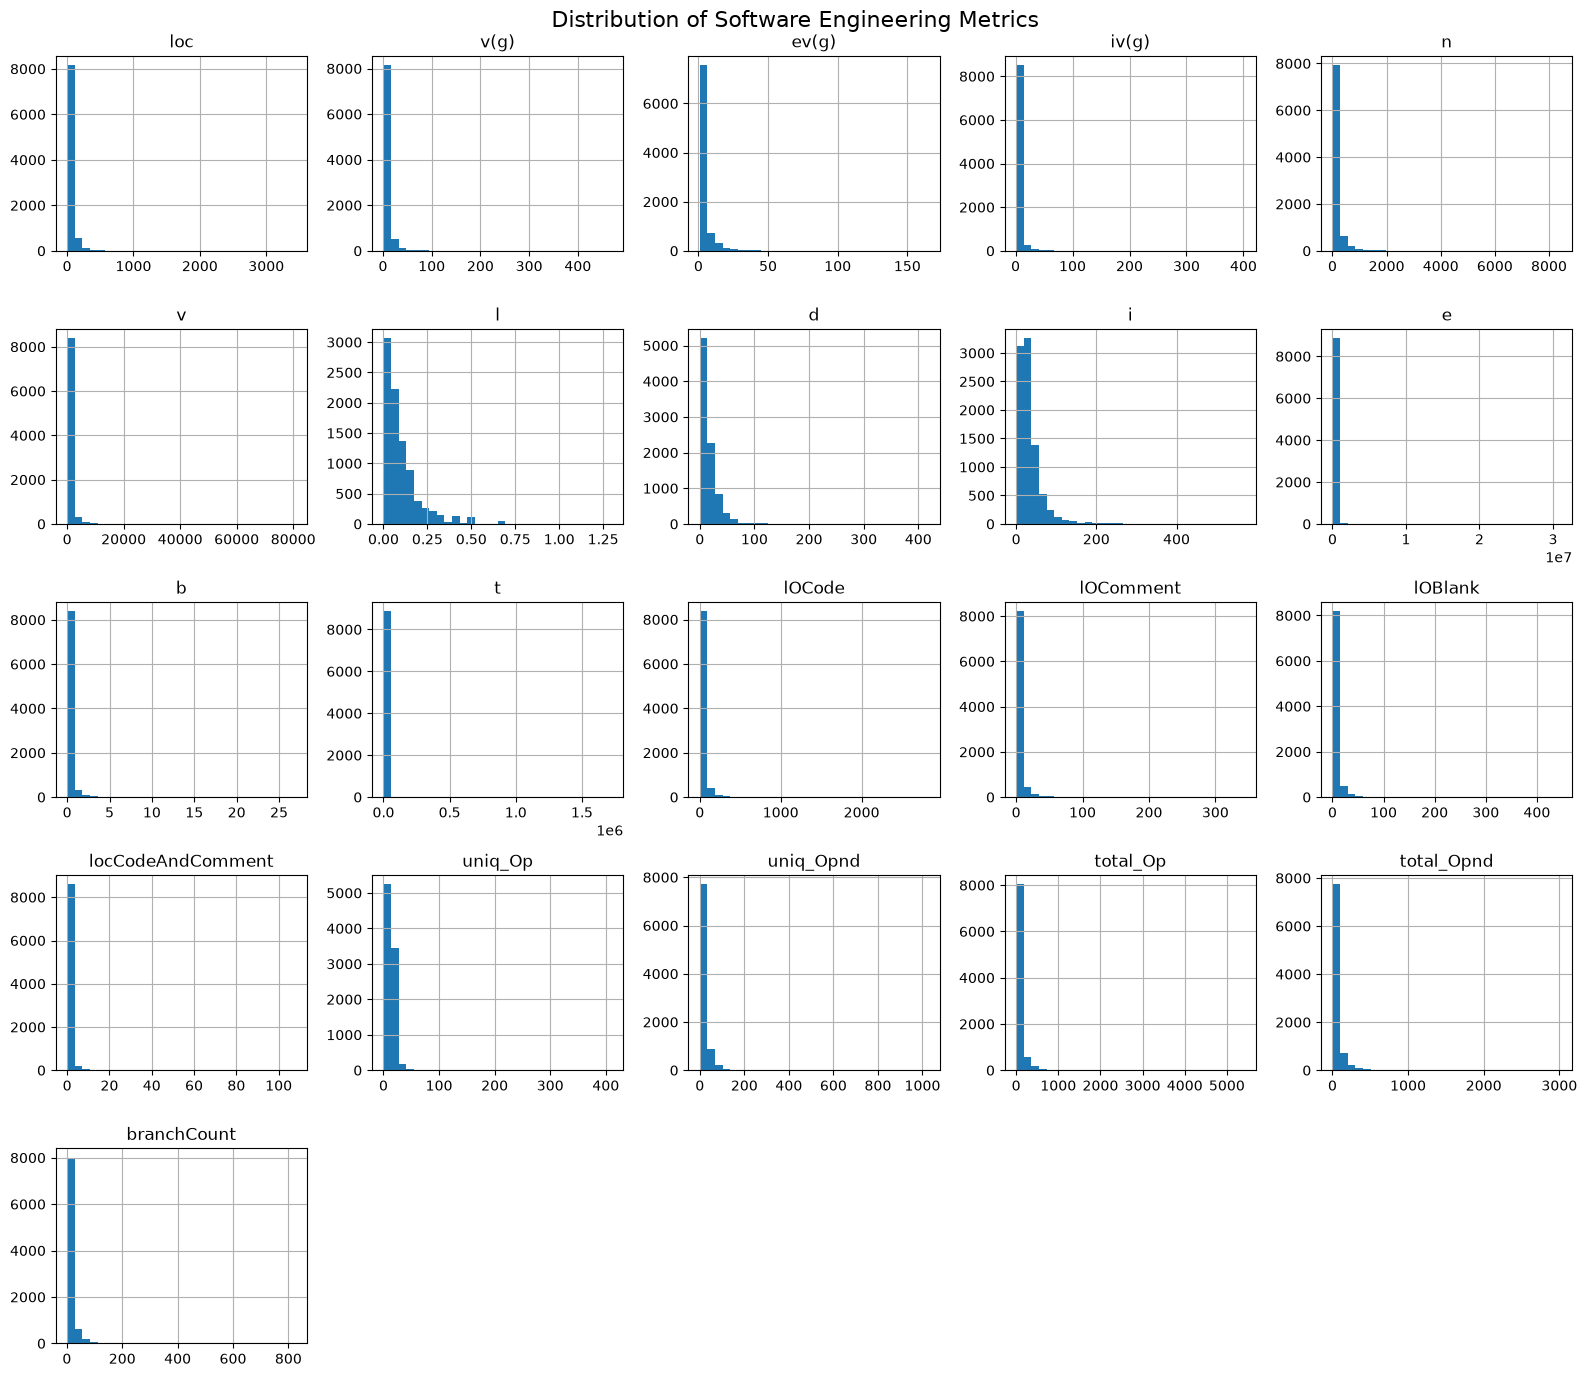

In [ ]:
feature_columns = [col for col in df.columns if col != "defects"]

df[feature_columns].hist(
    figsize=(16, 14),
    bins=30
)

plt.suptitle("Distribution of Software Engineering Metrics", fontsize=16)

plt.tight_layout()
plt.show()

In [ ]:
skewness = df[feature_columns].skew().sort_values(ascending=False)

print("Feature skewness:")
print(skewness)

Feature skewness:
t                    41.863934
e                    41.863934
locCodeAndComment    20.438847
iv(g)                19.912158
lOCode               16.523651
uniq_Op              15.463260
v                    14.479064
b                    14.473398
v(g)                 14.236258
loc                  14.057100
uniq_Opnd            13.137629
lOBlank              12.794477
branchCount          10.943875
total_Op             10.551780
lOComment            10.454431
n                     9.802648
total_Opnd            8.866419
ev(g)                 7.583095
d                     5.961897
i                     4.951373
l                     2.445387
dtype: float64


## 15. Feature Comparison by Defect Class

The software engineering metrics are compared between defective and non-defective modules.

This analysis helps identify whether certain code characteristics tend to differ between the two defect classes.

In [ ]:
feature_comparison = df.groupby("defects")[feature_columns].median().T

feature_comparison.columns = [
    "Non-Defective",
    "Defective"
]

feature_comparison

,Non-Defective,Defective
loc,24.00,47.00
v(g),4.00,6.00
ev(g),1.00,1.00
iv(g),2.00,4.00
n,58.00,103.00
v,266.27,528.81
l,0.07,0.04
d,10.63,14.95
i,23.97,31.82
e,2911.97,7870.37


## 16. Feature Correlation Analysis

The correlation between software engineering metrics and the defect target is examined.

Correlation helps identify features that have stronger or weaker linear relationships with defect occurrence. It is used as an exploratory analysis and does not imply causation.

In [ ]:
correlation_with_defects = (
    df[feature_columns + ["defects"]]
    .corr()["defects"]
    .drop("defects")
    .sort_values(ascending=False)
)

print("Correlation of features with defects:")
print(correlation_with_defects)

Correlation of features with defects:
loc                  0.224833
branchCount          0.203805
v(g)                 0.191450
uniq_Opnd            0.187274
n                    0.184597
total_Opnd           0.183429
total_Op             0.181781
lOBlank              0.177874
lOCode               0.177007
b                    0.174139
v                    0.173984
iv(g)                0.168240
i                    0.163717
ev(g)                0.157489
lOComment            0.146006
d                    0.139824
uniq_Op              0.123452
locCodeAndComment    0.109063
t                    0.083198
e                    0.083198
l                   -0.125540
Name: defects, dtype: float64


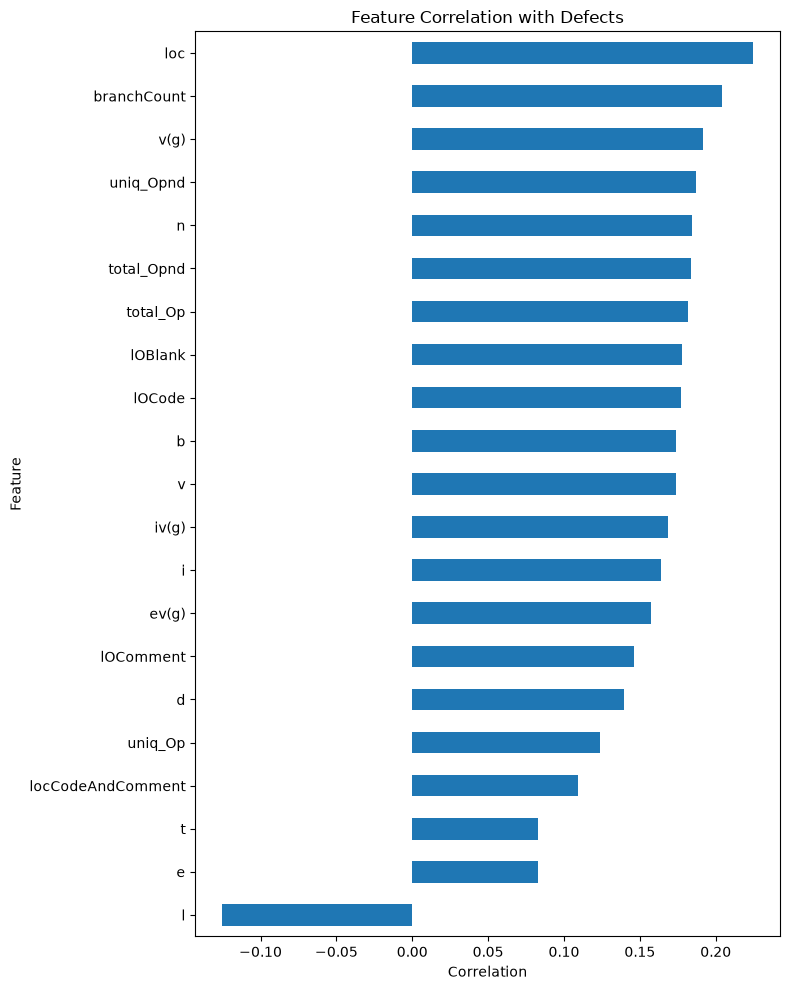

In [ ]:
plt.figure(figsize=(8, 10))

correlation_with_defects.sort_values().plot(
    kind="barh"
)

plt.title("Feature Correlation with Defects")
plt.xlabel("Correlation")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## 17. Feature Correlation Heatmap

A correlation heatmap is used to examine relationships between all software engineering metrics and identify highly correlated features.

This can help detect potential multicollinearity before model training.

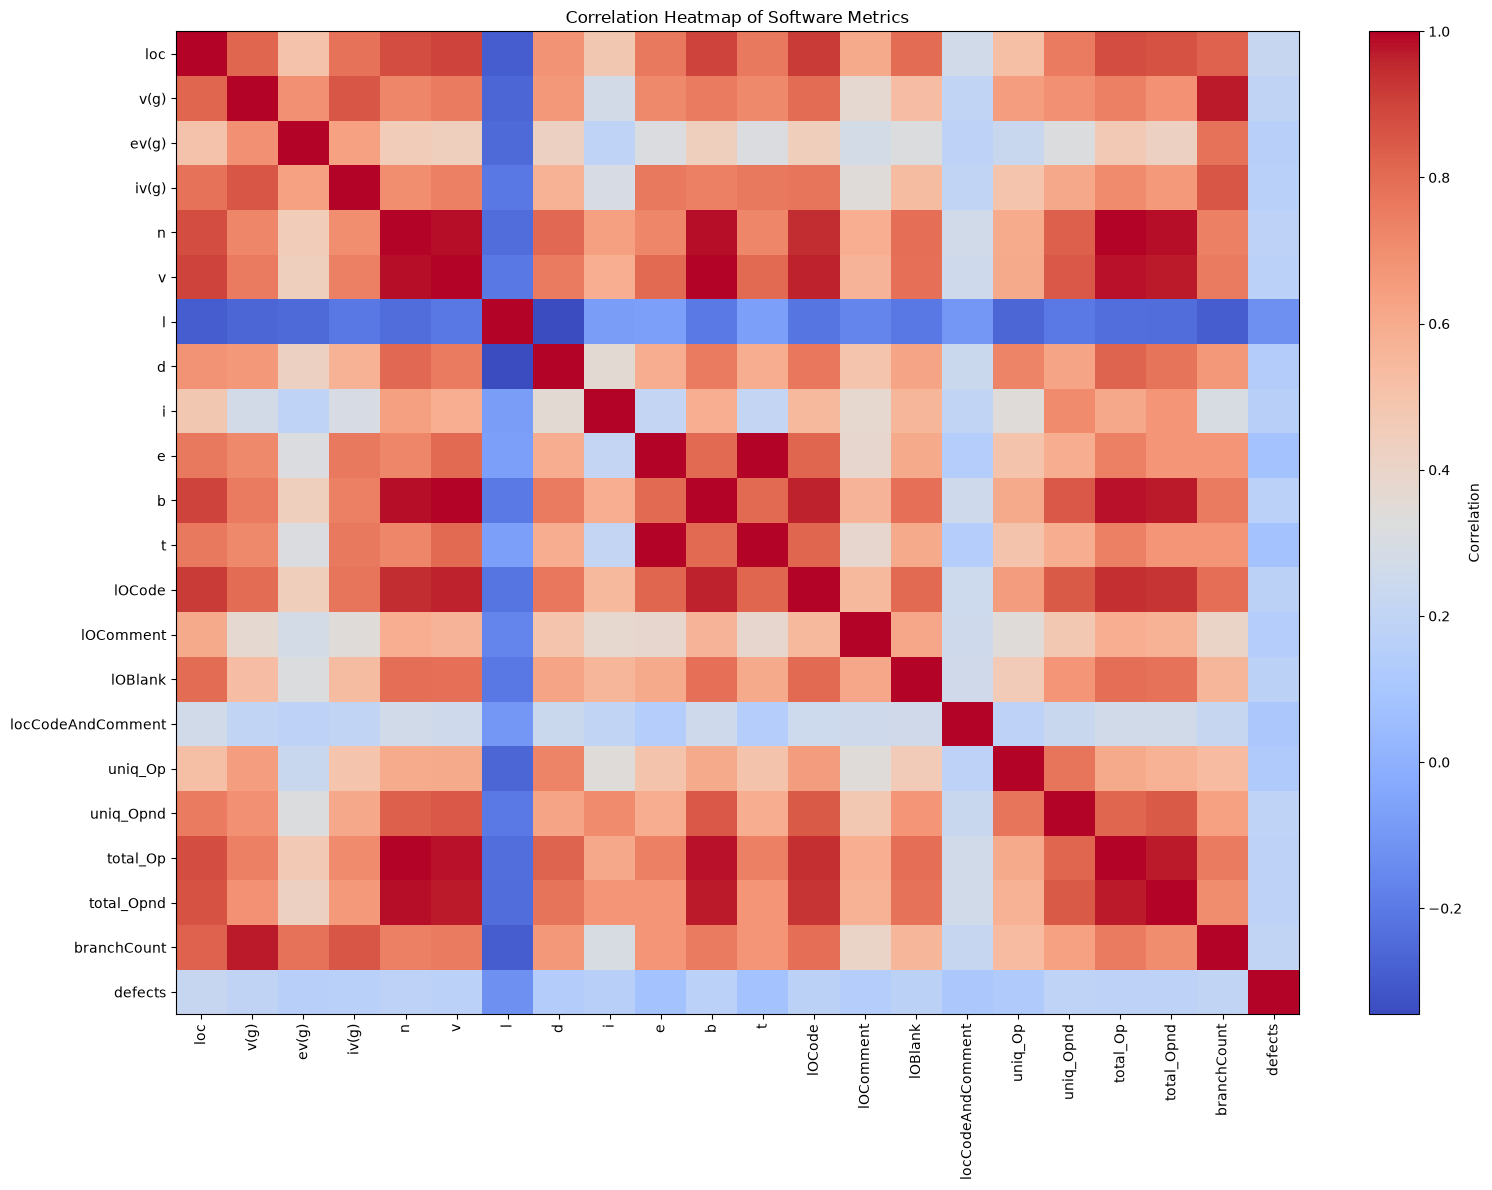

In [ ]:
correlation_matrix = df[feature_columns + ["defects"]].corr()

plt.figure(figsize=(16, 12))

plt.imshow(correlation_matrix, cmap="coolwarm", aspect="auto")

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Heatmap of Software Metrics")

plt.tight_layout()
plt.show()

## 18. Highly Correlated Feature Pairs

Highly correlated feature pairs are identified to detect potential multicollinearity among software metrics.

These relationships will be considered during preprocessing and model selection.

In [ ]:
correlation_matrix = df[feature_columns].corr()

high_correlation_pairs = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        
        correlation_value = correlation_matrix.iloc[i, j]
        
        if abs(correlation_value) >= 0.80:
            high_correlation_pairs.append(
                (
                    correlation_matrix.columns[i],
                    correlation_matrix.columns[j],
                    correlation_value
                )
            )

high_correlation_pairs = sorted(
    high_correlation_pairs,
    key=lambda x: abs(x[2]),
    reverse=True
)

for feature1, feature2, correlation in high_correlation_pairs:
    print(f"{feature1} <-> {feature2}: {correlation:.3f}")

e <-> t: 1.000
v <-> b: 1.000
n <-> total_Op: 0.996
n <-> total_Opnd: 0.989
n <-> v: 0.985
n <-> b: 0.984
v <-> total_Op: 0.982
b <-> total_Op: 0.982
v <-> total_Opnd: 0.972
total_Op <-> total_Opnd: 0.972
b <-> total_Opnd: 0.972
v(g) <-> branchCount: 0.971
v <-> lOCode: 0.962
b <-> lOCode: 0.962
n <-> lOCode: 0.943
lOCode <-> total_Op: 0.941
lOCode <-> total_Opnd: 0.929
loc <-> lOCode: 0.921
loc <-> v: 0.900
loc <-> b: 0.900
loc <-> n: 0.879
loc <-> total_Op: 0.879
loc <-> total_Opnd: 0.865
v(g) <-> iv(g): 0.857
iv(g) <-> branchCount: 0.857
v <-> uniq_Opnd: 0.851
b <-> uniq_Opnd: 0.851
uniq_Opnd <-> total_Opnd: 0.847
lOCode <-> uniq_Opnd: 0.844
n <-> uniq_Opnd: 0.831
loc <-> branchCount: 0.825
d <-> total_Op: 0.816
e <-> lOCode: 0.816
t <-> lOCode: 0.816
loc <-> v(g): 0.813
uniq_Opnd <-> total_Op: 0.811
n <-> d: 0.806
v <-> e: 0.804
v <-> t: 0.804
b <-> t: 0.804
e <-> b: 0.804
lOCode <-> lOBlank: 0.802


In [ ]:
# Find features that have high correlation with other features
features_to_remove = set()

for feature1, feature2, correlation in high_correlation_pairs:
    features_to_remove.add(feature2)

print("Features to consider removing:")
print(sorted(features_to_remove))

Features to consider removing:
['b', 'branchCount', 'd', 'e', 'iv(g)', 'lOBlank', 'lOCode', 'n', 't', 'total_Op', 'total_Opnd', 'uniq_Opnd', 'v', 'v(g)']


## 19. Feature Comparison by Defect Status

The distributions of selected software engineering metrics are compared between defective and non-defective modules.

This analysis helps identify differences in code size and complexity between the two classes.

<Figure size 700x500 with 0 Axes>

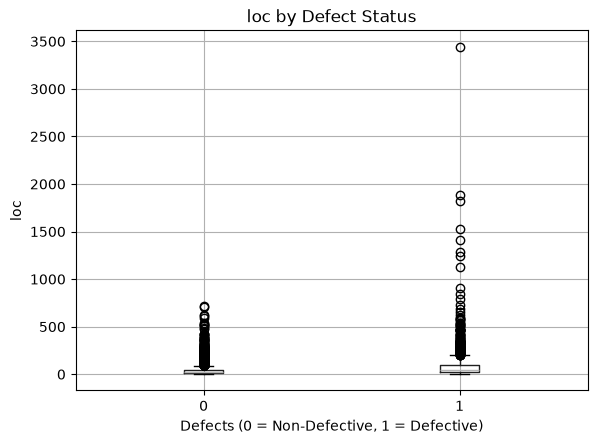

<Figure size 700x500 with 0 Axes>

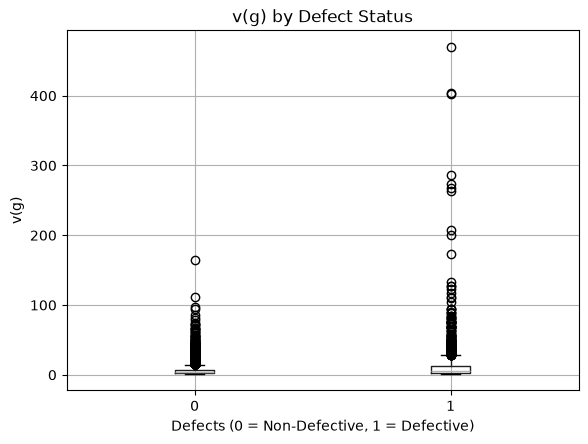

<Figure size 700x500 with 0 Axes>

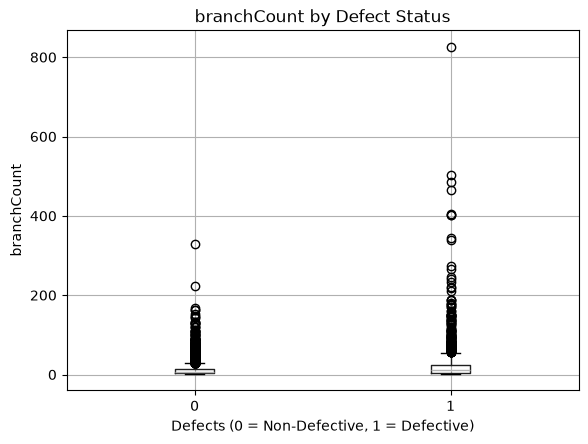

<Figure size 700x500 with 0 Axes>

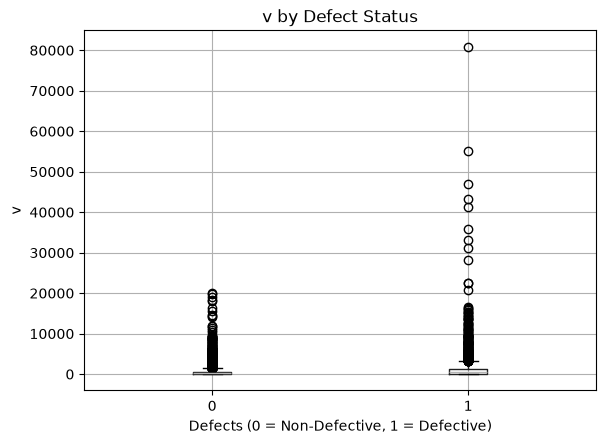

<Figure size 700x500 with 0 Axes>

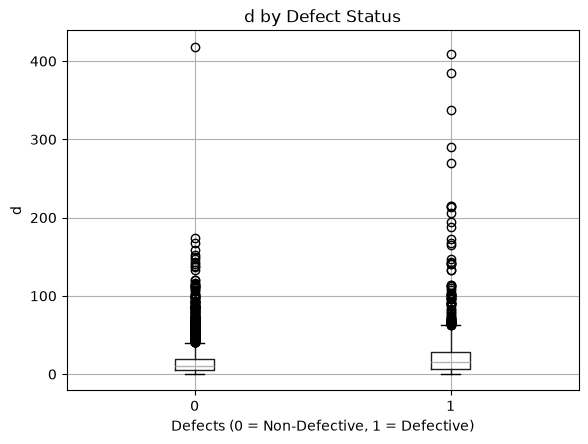

<Figure size 700x500 with 0 Axes>

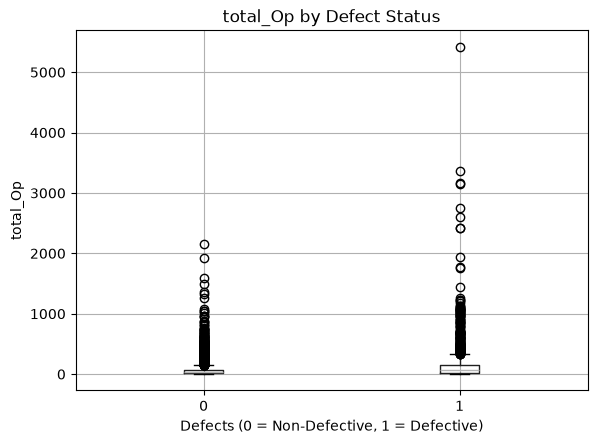

<Figure size 700x500 with 0 Axes>

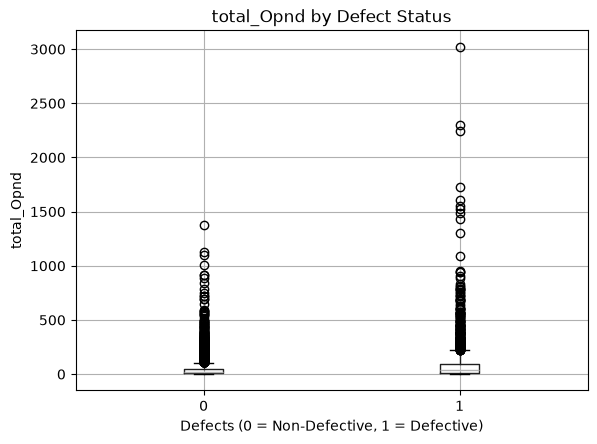

In [ ]:
selected_features = [
    "loc",
    "v(g)",
    "branchCount",
    "v",
    "d",
    "total_Op",
    "total_Opnd"
]

for feature in selected_features:
    
    plt.figure(figsize=(7, 5))
    
    df.boxplot(
        column=feature,
        by="defects"
    )
    
    plt.title(f"{feature} by Defect Status")
    plt.suptitle("")
    plt.xlabel("Defects (0 = Non-Defective, 1 = Defective)")
    plt.ylabel(feature)
    
    plt.show()

## 19. Key EDA Insights

The exploratory analysis produced the following observations:

1. The dataset contains 8,912 software-module records after removing exact duplicate rows.

2. The target variable is moderately imbalanced:
   - Non-defective modules: 6,905
   - Defective modules: 2,007
   - Defective modules represent approximately 22.52% of the dataset.

3. Several software metrics are strongly right-skewed, particularly `t`, `e`, `locCodeAndComment`, `iv(g)`, and `lOCode`.

4. Defective modules generally show higher median values for several size and complexity metrics, including:
   - `loc`
   - `v(g)`
   - `iv(g)`
   - `n`
   - `v`
   - `d`
   - `i`
   - `e`
   - `t`
   - `total_Op`
   - `total_Opnd`
   - `branchCount`

5. `loc` has the strongest individual positive correlation with the defect label, followed by `branchCount`, `v(g)`, `uniq_Opnd`, and `n`.

6. Several software metrics are strongly correlated with each other because they measure related aspects of software size and complexity.

7. The boxplot analysis shows differences in the distributions of important software metrics between defective and non-defective modules.

8. The presence of skewed features, correlated metrics, and class imbalance will be considered during preprocessing and model development.

## 20. EDA Conclusion

The exploratory analysis indicates that software size and complexity metrics contain potentially useful information for predicting software defects.

However, no single feature is sufficient to reliably identify defective modules. Therefore, multiple software metrics will be combined using Machine Learning classification models.

The next stage focuses on preparing the features, handling skewed distributions, preventing data leakage, and creating training and testing datasets for model development.